In [2]:
import pandas as pd
import numpy as np
import tensorflow
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
df = pd.read_csv("Churn_Modelling.csv")
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [12]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [14]:
df.shape

(10000, 14)

In [16]:
#will remove unwanted columns first

In [18]:
df.drop(['RowNumber','CustomerId','Surname'],inplace=True ,axis=1)


In [20]:
df1 =df.copy()
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [22]:
df1.nunique()

CreditScore         460
Geography             3
Gender                2
Age                  70
Tenure               11
Balance            6382
NumOfProducts         4
HasCrCard             2
IsActiveMember        2
EstimatedSalary    9999
Exited                2
dtype: int64

In [24]:
for column in df1:
    print(f'{column} :{df1[column].dtype}: {df1[column].nunique()} :')

CreditScore :int64: 460 :
Geography :object: 3 :
Gender :object: 2 :
Age :int64: 70 :
Tenure :int64: 11 :
Balance :float64: 6382 :
NumOfProducts :int64: 4 :
HasCrCard :int64: 2 :
IsActiveMember :int64: 2 :
EstimatedSalary :float64: 9999 :
Exited :int64: 2 :


In [26]:
df1['Tenure'].skew()

0.01099145797717904

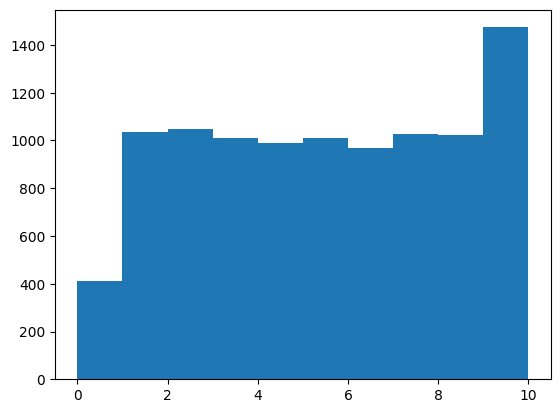

In [28]:
plt.hist(df1['Tenure'])
plt.show()

In [29]:
exited_yes_users = df1[df1['Exited']==1]
exited_yes_users

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
16,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1
...,...,...,...,...,...,...,...,...,...,...,...
9981,498,Germany,Male,42,3,152039.70,1,1,1,53445.17,1
9982,655,Germany,Female,46,7,137145.12,1,1,0,115146.40,1
9991,597,France,Female,53,4,88381.21,1,1,0,69384.71,1
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1


In [30]:
exited_yes_users.shape

(2037, 11)

In [34]:
exited_no_users = df1[df1['Exited']==0]
exited_no_users

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
...,...,...,...,...,...,...,...,...,...,...,...
9993,644,France,Male,28,7,155060.41,1,1,0,29179.52,0
9994,800,France,Female,29,2,0.00,2,0,0,167773.55,0
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0


In [35]:
exited_no_users.shape

(7963, 11)

In [37]:
df1.shape

(10000, 11)

In [40]:
tenure_of_exited_yes = exited_yes_users.Tenure
tenure_of_exited_yes

0       2
2       8
5       8
7       4
16      1
       ..
9981    3
9982    7
9991    4
9997    7
9998    3
Name: Tenure, Length: 2037, dtype: int64

In [42]:
tenure_of_exited_no=exited_no_users.Tenure
tenure_of_exited_no

1        1
3        1
4        2
6        7
8        4
        ..
9993     7
9994     2
9995     5
9996    10
9999     4
Name: Tenure, Length: 7963, dtype: int64

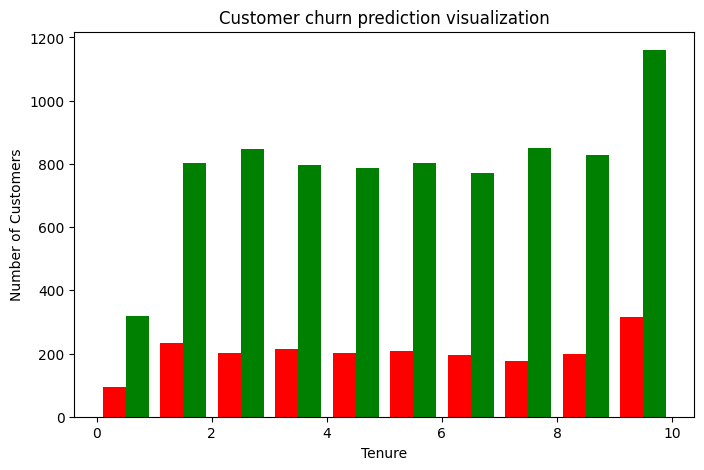

In [44]:
plt.figure(figsize=(8,5))
plt.hist([tenure_of_exited_yes, tenure_of_exited_no], color =['red', 'green'], label = ["Exited =Yes", "Exited = No"])
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.title("Customer churn prediction visualization")
plt.show()

In [46]:
df1.nunique()

CreditScore         460
Geography             3
Gender                2
Age                  70
Tenure               11
Balance            6382
NumOfProducts         4
HasCrCard             2
IsActiveMember        2
EstimatedSalary    9999
Exited                2
dtype: int64

In [48]:
EstimatedSalary_of_exited_yes = exited_yes_users.EstimatedSalary
EstimatedSalary_of_exited_yes

0       101348.88
2       113931.57
5       149756.71
7       119346.88
16        5097.67
          ...    
9981     53445.17
9982    115146.40
9991     69384.71
9997     42085.58
9998     92888.52
Name: EstimatedSalary, Length: 2037, dtype: float64

In [50]:
EstimatedSalary_of_exited_no = exited_no_users.EstimatedSalary
EstimatedSalary_of_exited_no

1       112542.58
3        93826.63
4        79084.10
6        10062.80
8        74940.50
          ...    
9993     29179.52
9994    167773.55
9995     96270.64
9996    101699.77
9999     38190.78
Name: EstimatedSalary, Length: 7963, dtype: float64

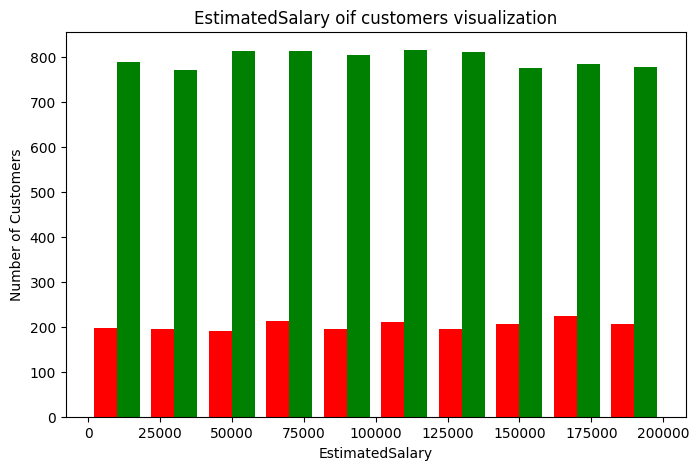

In [52]:
plt.figure(figsize=(8,5))
plt.hist([EstimatedSalary_of_exited_yes, EstimatedSalary_of_exited_no], color =['red', 'green'], label = ["Exited =Yes", "Exited = No"])
plt.xlabel("EstimatedSalary")
plt.ylabel("Number of Customers")
plt.title("EstimatedSalary oif customers visualization")
plt.show()

In [53]:
for column in df1:
    print(f'{column} : {df1[column].unique()}') 

CreditScore : [619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 620 676 572 695 592
 567 694 547 594 673 610 767 763 712 703 662 659 523 772 545 634 739 771
 681 544 696 766 727 693 557 531 498 651 791 733 811 707 714 782 775 799
 602 744 588 747 583 627 731 629 438 642 806 474 559 429 680 749 734 644
 626 649 805 718 840 630 654 762 568 613 522 737 648 443 640 540 460 593
 801 611 802 745 483 690 492 709 705 

In [56]:
df1['Gender'].replace({'Female':1, 'Male':0}, inplace=True)

C:\Users\dell\AppData\Local\Temp\ipykernel_23608\4070406045.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Gender'].replace({'Female':1, 'Male':0}, inplace=True)
C:\Users\dell\AppData\Local\Temp\ipykernel_23608\4070406045.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['Gender'].re

In [58]:
df2 =df1.copy()
for column in df2:
    print(f'{column} : {df2[column].unique()}') 

CreditScore : [619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 620 676 572 695 592
 567 694 547 594 673 610 767 763 712 703 662 659 523 772 545 634 739 771
 681 544 696 766 727 693 557 531 498 651 791 733 811 707 714 782 775 799
 602 744 588 747 583 627 731 629 438 642 806 474 559 429 680 749 734 644
 626 649 805 718 840 630 654 762 568 613 522 737 648 443 640 540 460 593
 801 611 802 745 483 690 492 709 705 

In [60]:
df3 = pd.get_dummies(df2, columns=['Geography'], dtype=int)

In [62]:
df3.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,1,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,1,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [64]:
df4 =df3.copy()
for column in df3:
    print(f'{column} : {df3[column].unique()}') 

CreditScore : [619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 620 676 572 695 592
 567 694 547 594 673 610 767 763 712 703 662 659 523 772 545 634 739 771
 681 544 696 766 727 693 557 531 498 651 791 733 811 707 714 782 775 799
 602 744 588 747 583 627 731 629 438 642 806 474 559 429 680 749 734 644
 626 649 805 718 840 630 654 762 568 613 522 737 648 443 640 540 460 593
 801 611 802 745 483 690 492 709 705 

In [66]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_France   10000 non-null  int32  
 11  Geography_Germany  10000 non-null  int32  
 12  Geography_Spain    10000 non-null  int32  
dtypes: float64(2), int32(3), int64(8)
memory usage: 898.6 KB


In [68]:
#will scale

In [70]:
cols_to_scale = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df4[cols_to_scale] = scaler.fit_transform(df4[cols_to_scale])

In [71]:
df4.sample(5)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
766,0.700,1,0.864865,0.2,0.000000,0.333333,0,1,0.910306,0,1,0,0
5663,1.000,1,0.270270,0.2,0.000000,0.333333,1,0,0.045022,0,1,0,0
8131,0.526,0,0.202703,0.3,0.620716,0.333333,1,1,0.288726,0,0,1,0
5905,0.322,1,0.162162,0.5,0.000000,0.333333,1,0,0.719985,0,1,0,0
1338,0.550,0,0.459459,0.5,0.657550,0.000000,1,1,0.338917,0,1,0,0


In [72]:
#now will build the model

In [73]:
X= df4.drop('Exited', axis=1)
X

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,0.538,1,0.324324,0.2,0.000000,0.000000,1,1,0.506735,1,0,0
1,0.516,1,0.310811,0.1,0.334031,0.000000,0,1,0.562709,0,0,1
2,0.304,1,0.324324,0.8,0.636357,0.666667,1,0,0.569654,1,0,0
3,0.698,1,0.283784,0.1,0.000000,0.333333,0,0,0.469120,1,0,0
4,1.000,1,0.337838,0.2,0.500246,0.000000,1,1,0.395400,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.842,0,0.283784,0.5,0.000000,0.333333,1,0,0.481341,1,0,0
9996,0.332,0,0.229730,1.0,0.228657,0.000000,1,1,0.508490,1,0,0
9997,0.718,1,0.243243,0.7,0.000000,0.000000,0,1,0.210390,1,0,0
9998,0.844,0,0.324324,0.3,0.299226,0.333333,1,0,0.464429,0,1,0


In [74]:
y=df4['Exited']
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=15)

In [76]:
len(X_train)

8000

In [80]:
len(X_test)

2000

In [83]:
len(X_train.columns)

12

In [86]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(20, input_shape=(12,), activation='relu'),
    keras.layers.Dense(15, input_shape=(12,), activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),
    
])

model.compile(optimizer = 'adam',
              loss='binary_crossentropy',
              metrics=(['accuracy'])
)

model.fit(X_train, y_train, epochs=100)

Epoch 1/100
250/250 [==============================] - 2s 3ms/step - loss: 0.5388 - accuracy: 0.7695
Epoch 2/100
250/250 [==============================] - 1s 2ms/step - loss: 0.4739 - accuracy: 0.7951
Epoch 3/100
250/250 [==============================] - 1s 2ms/step - loss: 0.4557 - accuracy: 0.8004
Epoch 4/100
250/250 [==============================] - 1s 2ms/step - loss: 0.4415 - accuracy: 0.8083
Epoch 5/100
250/250 [==============================] - 1s 2ms/step - loss: 0.4313 - accuracy: 0.8104
Epoch 6/100
250/250 [==============================] - 1s 2ms/step - loss: 0.4258 - accuracy: 0.8148
Epoch 7/100
250/250 [==============================] - 1s 2ms/step - loss: 0.4219 - accuracy: 0.8164
Epoch 8/100
250/250 [==============================] - 1s 2ms/step - loss: 0.4171 - accuracy: 0.8194
Epoch 9/100
250/250 [==============================] - 1s 2ms/step - loss: 0.4130 - accuracy: 0.8234
Epoch 10/100
250/250 [==============================] - 1s 2ms/step - loss: 0.4101 - accura

In [88]:
model.evaluate(X_test, y_test)

63/63 [==============================] - 1s 3ms/step - loss: 0.3406 - accuracy: 0.8580


[0.3405553698539734, 0.8579999804496765]

In [90]:
yp = model.predict(X_test)
yp[:10]

63/63 [==============================] - 0s 2ms/step


array([[0.05177843],
       [0.02670056],
       [0.4020651 ],
       [0.02092001],
       [0.09522898],
       [0.02439284],
       [0.34311846],
       [0.02331809],
       [0.01756546],
       [0.30652076]], dtype=float32)

In [94]:
y_test[:10]

522     0
5667    0
4030    0
3198    0
2902    0
3357    0
4356    0
3105    1
14      0
4304    0
Name: Exited, dtype: int64

In [96]:
y_pred =[]
for element in yp:
    if element>0.3:
        y_pred.append(1)

    else :
        y_pred.append(0)
    

In [98]:
y_pred[:10]

[0, 0, 1, 0, 0, 0, 1, 0, 0, 1]

In [100]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1596
           1       0.56      0.67      0.61       404

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.83      2000



Text(70.72222222222221, 0.5, 'Truth')

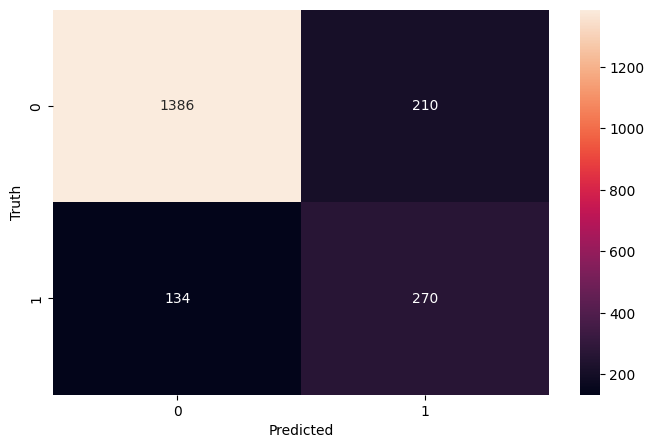

In [102]:
import seaborn as sn
cm=tf.math.confusion_matrix(labels=y_test, predictions=y_pred)

plt.figure(figsize=(8,5))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [104]:
#in here we can see unbalanced so romuve it will use smoke method

In [106]:
from imblearn.over_sampling import SMOTE

In [108]:
smote = SMOTE(sampling_strategy= 'minority')
X_sm, y_sm = smote.fit_resample(X,y)

y_sm.value_counts()

Exited
1    7963
0    7963
Name: count, dtype: int64

In [116]:
from sklearn.model_selection import train_test_split
X_train_sm, X_test_sm, y_train_sm,y_test_sm = train_test_split(X_sm,y_sm, test_size=0.2, random_state=15)

In [118]:
import tensorflow as tf
from tensorflow import keras

modeld = keras.Sequential([
    keras.layers.Dense(20, input_shape=(12,), activation='relu'),
    keras.layers.Dense(15, input_shape=(12,), activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),
    
])

modeld.compile(optimizer = 'adam',
              loss='binary_crossentropy',
              metrics=(['accuracy'])
)

modeld.fit(X_train_sm, y_train_sm, epochs=100)

Epoch 1/100
399/399 [==============================] - 2s 3ms/step - loss: 0.6235 - accuracy: 0.6552
Epoch 2/100
399/399 [==============================] - 1s 3ms/step - loss: 0.5634 - accuracy: 0.7162
Epoch 3/100
399/399 [==============================] - 1s 3ms/step - loss: 0.5232 - accuracy: 0.7429
Epoch 4/100
399/399 [==============================] - 1s 3ms/step - loss: 0.4949 - accuracy: 0.7649
Epoch 5/100
399/399 [==============================] - 1s 3ms/step - loss: 0.4815 - accuracy: 0.7700
Epoch 6/100
399/399 [==============================] - 1s 3ms/step - loss: 0.4738 - accuracy: 0.7736
Epoch 7/100
399/399 [==============================] - 1s 3ms/step - loss: 0.4692 - accuracy: 0.7775
Epoch 8/100
399/399 [==============================] - 1s 3ms/step - loss: 0.4664 - accuracy: 0.7761
Epoch 9/100
399/399 [==============================] - 1s 3ms/step - loss: 0.4637 - accuracy: 0.7801
Epoch 10/100
399/399 [==============================] - 1s 3ms/step - loss: 0.4614 - accura

In [122]:
modeld.evaluate(X_test_sm, y_test_sm)

100/100 [==============================] - 0s 2ms/step - loss: 0.4186 - accuracy: 0.8079


[0.41856545209884644, 0.8079096078872681]

In [144]:
yp = modeld.predict(X_test_sm)
yp[:10]

100/100 [==============================] - 0s 2ms/step


array([[0.6429858 ],
       [0.0172168 ],
       [0.23849441],
       [0.88104475],
       [0.58518875],
       [0.96477956],
       [0.7490324 ],
       [0.5918471 ],
       [0.9991943 ],
       [0.01026617]], dtype=float32)

In [146]:
y_test_sm[:10]

5510     1
7913     0
1048     0
14751    1
8392     1
2344     1
9746     0
11968    1
1488     1
9188     0
Name: Exited, dtype: int64

In [148]:
y_pred_sm=[]
for element in yp:
    if element>0.5:
        y_pred_sm.append(1)

    else :
        y_pred_sm.append(0)
    

In [150]:
y_pred_sm[:10]

[1, 0, 0, 1, 1, 1, 1, 1, 1, 0]

In [152]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test_sm, y_pred_sm))


              precision    recall  f1-score   support

           0       0.83      0.78      0.81      1632
           1       0.79      0.83      0.81      1554

    accuracy                           0.81      3186
   macro avg       0.81      0.81      0.81      3186
weighted avg       0.81      0.81      0.81      3186



Text(70.72222222222221, 0.5, 'Truth')

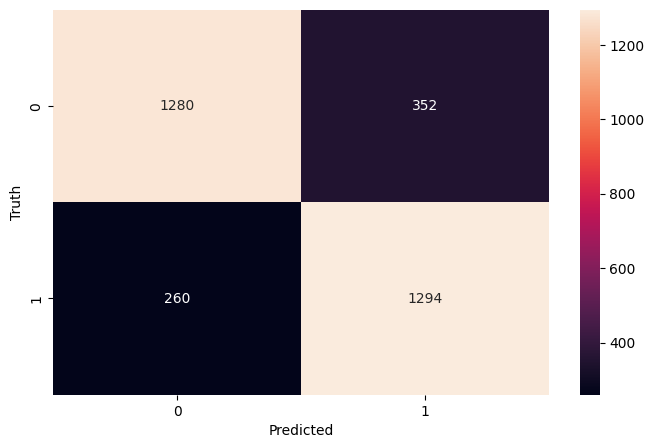

In [154]:
import seaborn as sn
cm=tf.math.confusion_matrix(labels=y_test_sm, predictions=y_pred_sm)

plt.figure(figsize=(8,5))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')